# Building Decision Trees - LAB01
### K.P.B.P. KARUNANAYAKE - E/22/184

#### i. Importing libraries

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

#### ii. Dataset loading and exploratory data analysis


In [ ]:
#Loading Dataset
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df.head() # Preview the dataset
diabetes_df.shape # Number of instances and variables

(768, 9)

In [ ]:
#Renaming columns
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
diabetes_df.columns = col_names # Rename column names

In [ ]:
diabetes_df.info()    #Summary of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   bp        768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   bmi       768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#Frequency distributions of values in variables
for col in col_names:
    print(diabetes_df[col].value_counts())

pregnant
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64
glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64
bp
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64
skin
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
29     17
25     16
40  

In [ ]:
diabetes_df['label'].value_counts()  #Exploring target variable

label
0    500
1    268
Name: count, dtype: int64

In [ ]:
diabetes_df.isnull().sum() #Checking missing values in variables

pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

#### iii. Defining feature vector and target variable

In [ ]:
X = diabetes_df.drop(['label'], axis=1)
y = diabetes_df['label']

#### iv. Splitting data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1) # 75% training and 25% test
X_train.shape, X_test.shape # Shapes of X_train and X_test

((576, 8), (192, 8))

#### v. Feature engineering: encoding categorical variables

This is the process of transforming raw data into useful features that help us better
understand our model and increase its predictive power.

In [ ]:
X_train.dtypes # Check data types in X_train
import category_encoders as ce
encoder = ce.OrdinalEncoder(cols=X.columns.tolist())
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

#### vi. Building decision tree classifier with the Gini index criterion

In [ ]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0)
clf_gini.fit(X_train, y_train) # Train the classifier

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

#### vii. Predicting results for the test set

In [ ]:
y_pred = clf_gini.predict(X_test)

#### viii. Evaluating model

In [ ]:
print('Accuracy:', metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6875


#### ix. Confusion matrix

A confusion matrix is a matrix that can be used to measure the performance of a
machine learning algorithm, usually a supervised learning one. In general, each row of the
confusion matrix represents the instances of an actual class and each column represents
the instances of a predicted class, but it can be the other way around as well.
Four types of outcomes are possible while evaluating classification model performance:

• True Positives (TP) - True Positives occur when we predict an observation belongs
to a certain class and the observation actually belongs to that class.

• True Negatives (TN) - True Negatives occur when we predict an observation
does not belong to a certain class and the observation actually does not belong to
that class.

• False Positives (FP) - False Positives occur when we predict an observation
belongs to a certain class but the observation actually does not belong to that
class. This type of error is called Type I error.

• False Negatives (FN) - False Negatives occur when we predict an observation
does not belong to a certain class but the observation actually belongs to that class.

This is a very serious error, and it is called Type II error.

In [ ]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, y_pred)

#### 1.4 Optimizing Decision Tree Performance

In scikit-learn, optimization of a decision tree classifier is performed by pre-pruning.
Maximum depth of the tree can be used as a control variable for pre-pruning. In addition
to the pre-pruning parameters, other attribute selection measures such as entropy can be
used.

• criterion: optional, default = “gini”, or choose attribute selection measure. This
parameter allows us to use different attribute selection measures. Supported criteria
are “gini” for the Gini index and “entropy” for information gain.

• splitter: string, optional, default = “best”, or split strategy. This parameter allows
us to choose the split strategy. Supported strategies are “best” to choose the best
split and “random” to choose the best random split.

• max_depth: int or None, optional, default = None, or maximum depth of a tree.
This is the maximum depth of the tree. If None, then nodes are expanded until all
leaves contain less than min_samples_split samples. A higher value of maximum
depth may cause overfitting, and a lower value may cause underfitting.

#### 1.5 Visualizing Decision Trees

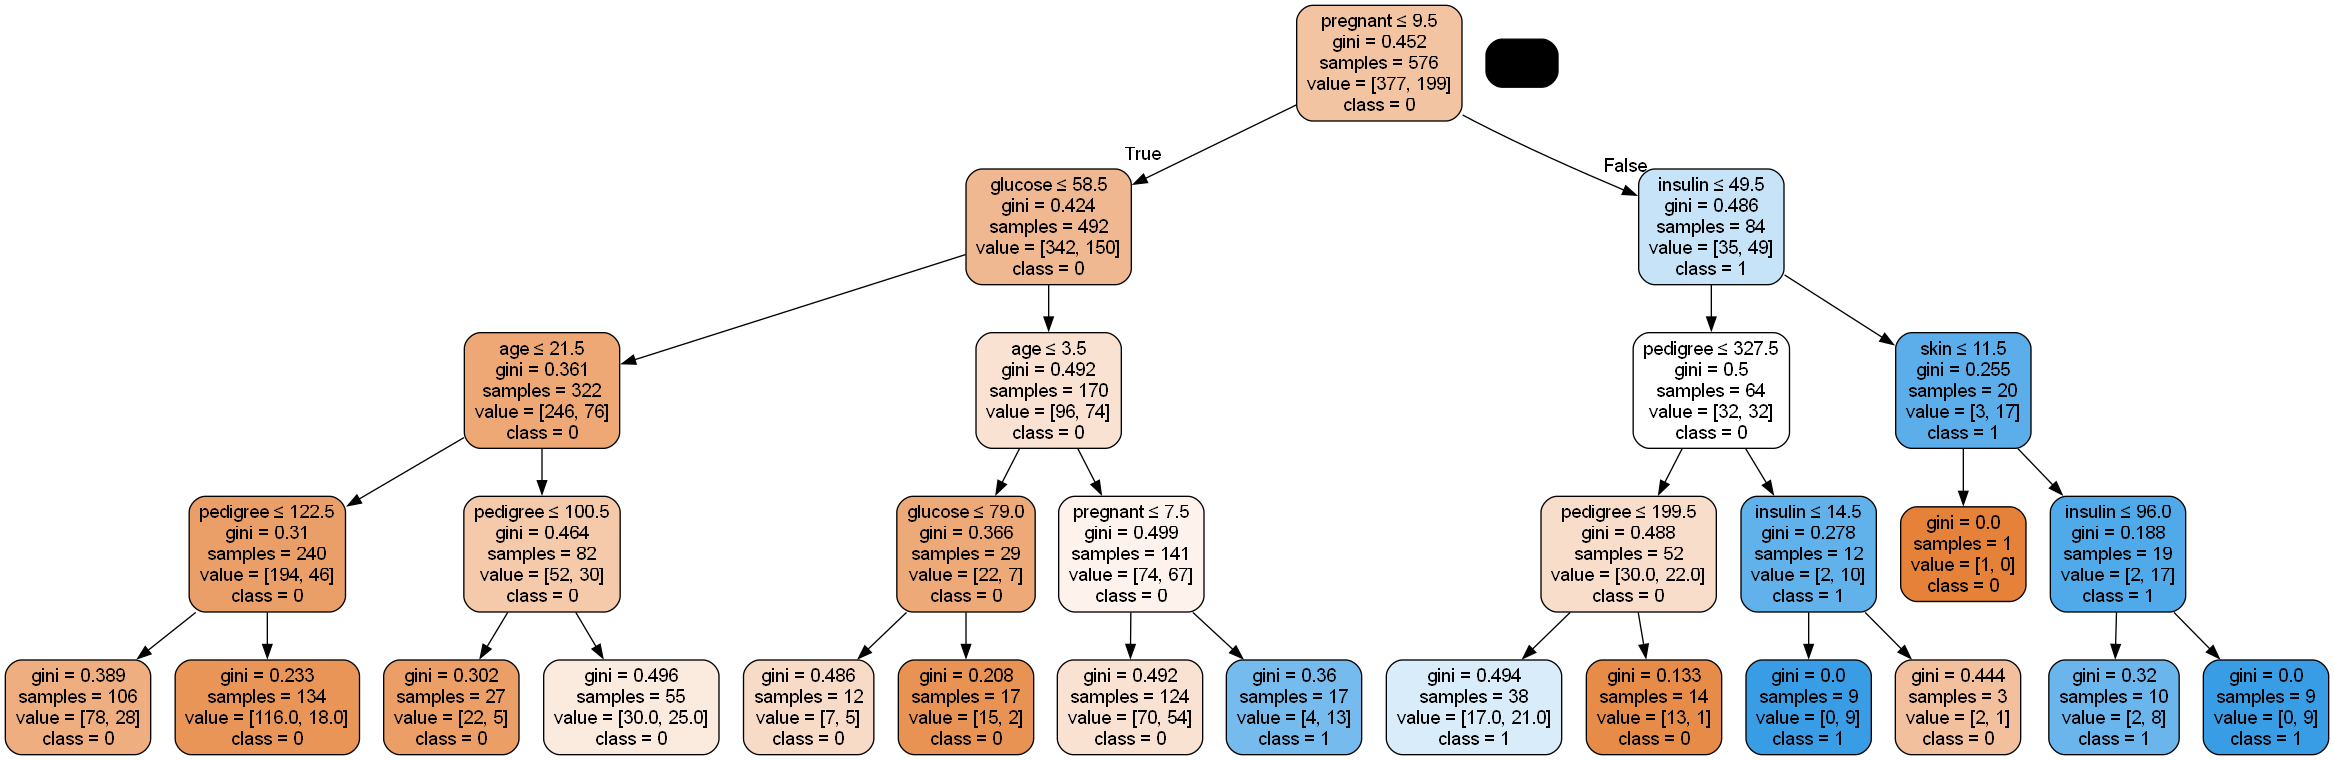

In [ ]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(
    clf_gini,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=X.columns,
    class_names=['0', '1']
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())